# Step 6: restricted-EWL ESS resolution

All four survivors are certified within the frozen restricted family. Read `docs/step6_methods.md` for the complete argument. This notebook inspects saved data and rederives the exact certificate; it does not treat numerical near-zero as mathematical equality. Steps 7-10 are not executed.

In [1]:
from pathlib import Path
import sys, json, gzip
import pandas as pd
from IPython.display import display, Image
ROOT = Path.cwd()
if not (ROOT/'src/quantum_ess').exists(): ROOT = ROOT.parent
sys.path.insert(0, str(ROOT/'src'))
DATA = ROOT/'results/step6'
meta = json.loads((DATA/'run_metadata.json').read_text())
display({k: meta[k] for k in ['git_head_at_run','step5_merge_commit','python','hardware','runtime_seconds','seeds','workers','tolerance']})

{'git_head_at_run': '447373ff87c6bbec8bdb28dc6c43f8e0d37b9286',
 'step5_merge_commit': '655c86574b6c989f25153c7ad500b5b15d6e8316',
 'python': '3.12.14 (main, Aug 12 2026, 13:57:54) [Clang 21.0.0 (clang-2100.3.34.2)]',
 'hardware': 'Apple M5 Max',
 'runtime_seconds': 9.347552207997069,
 'seeds': [20261002, 20261003, 20261004],
 'workers': 1,
 'tolerance': 1e-08}

## Four residents
The reported strongest candidates below are finite-grid maxima. The continuous near-self supremum has no distinct maximizing mutant.

In [2]:
summary = pd.read_csv(DATA/'resident_summary.csv')
display(summary[['resident','resident_theta','resident_phi','resident_payoff','step5_status','step6_status','mutant_theta','mutant_phi','distance','leading_order','leading_coefficient','power_coefficients','delta_001']])

,resident,resident_theta,resident_phi,resident_payoff,step5_status,step6_status,mutant_theta,mutant_phi,distance,leading_order,leading_coefficient,power_coefficients,delta_001
0,K2_Q,0.000000,1.570796,3.00,neutral_or_weak_candidate,proven_ESS_restricted_EWL,0.039270,1.570796,0.03927,0,-0.001156,"[-0.0011564456389159261,-1.4859627883723192e-07]",-0.001156
1,K4_Q,0.000000,1.570796,9.00,neutral_or_weak_candidate,proven_ESS_restricted_EWL,0.039270,1.570796,0.03927,0,-0.003469,"[-0.0034693369167477783,5.79525489996513e-06,-...",-0.003469
2,K4_B,1.570796,1.570796,6.75,neutral_or_weak_candidate,proven_ESS_restricted_EWL,1.531526,1.570796,0.03927,1,-0.001156,"[-8.881784197001252e-16,-0.0011559998500709767...",-0.000012
3,K5_A,0.000000,1.256637,12.00,neutral_or_weak_candidate,proven_ESS_restricted_EWL,0.039270,1.256637,0.03927,0,-0.003890,"[-0.0038895776757890133,8.026153949458603e-06,...",-0.003889


## Exact identities and complete tie set
Let x=cos(theta/2)cos(phi), y=cos(theta/2)sin(phi), s=sin(theta/2), with x,y,s>=0 and x²+y²+s²=1. Q and A have strictly negative a0 away from self. B has a0=-(9/2)sx, with a1=-3/4 on s=0 and a1=-(3/4)(2y²-1)² on x=0. Equality at the second stage occurs only at self B.

In [3]:
from quantum_ess.ewl_resolution import symbolic_certificate
cert = symbolic_certificate()
assert cert == json.loads((DATA/'certification_summary.json').read_text())
display(cert)
display(json.loads((DATA/'neutral_sets.json').read_text()))

{'K2_Q': {'a0_cartesian': '-3*s**2 - 2*x**2',
  'exact_checks': {'a0_identity_remainder': '0'},
  'status': 'proven_ESS_restricted_EWL',
  'scope': 'pointwise rare-mutant ESS for every fixed distinct pure mutant; restricted family only',
  'method': 'exact polynomial identities and sign/zero-set argument over positive unit octant'},
 'K4_Q': {'a0_cartesian': '-9*s**2 - 6*x**2',
  'exact_checks': {'a0_identity_remainder': '0'},
  'status': 'proven_ESS_restricted_EWL',
  'scope': 'pointwise rare-mutant ESS for every fixed distinct pure mutant; restricted family only',
  'method': 'exact polynomial identities and sign/zero-set argument over positive unit octant'},
 'K4_B': {'a0_cartesian': '-9*s*x/2',
  'exact_checks': {'a0_identity_remainder': '0',
   'a1_x0_remainder': '0',
   'a1_s0_remainder': '0'},
  'status': 'proven_ESS_restricted_EWL',
  'scope': 'pointwise rare-mutant ESS for every fixed distinct pure mutant; restricted family only',
  'method': 'exact polynomial identities and s

{'K2_Q': {'Z0_including_self': '{Q}', 'distinct_neutral_set': 'empty'},
 'K4_Q': {'Z0_including_self': '{Q}', 'distinct_neutral_set': 'empty'},
 'K5_A': {'Z0_including_self': '{(0,2*pi/5)}',
  'distinct_neutral_set': 'empty'},
 'K4_B': {'Z0_including_self': '{theta=0,0<=phi<=pi/2} union {phi=pi/2,0<=theta<=pi}; theta=pi aliases canonical D',
  'a1_theta0': '-3/4',
  'a1_phi_pi2': '-3/4*cos(theta)^2',
  'Z1_including_self': '{B}',
  'distinct_neutral_set': 'empty',
  'equality_evidence': 'exact polynomial remainders zero; independent 80-digit tensor evaluations'}}

## Convergence
Self-excluded canonical counts are 220, 840 and 3280 per resident. These grids support the exact proof but are not a proof themselves.

,resident,theta_count,phi_count,distinct_operations,mutants_excluding_self,maximum_delta_001,theta,phi,distance,strongest_leading_coefficient,corresponding_order,leading_theta,leading_phi,leading_distance,per_order_maxima,apparent_neutral_count,apparent_invader_count
0,K2_Q,21,11,221,220,-0.018468,0.157080,1.570796,0.15708,-0.018467,0,0.157080,1.570796,0.15708,"{""0"": -0.018467489107293567, ""1"": null}",0,0
1,K2_Q,41,21,841,840,-0.004624,0.078540,1.570796,0.07854,-0.004624,0,0.078540,1.570796,0.07854,"{""0"": -0.004623999400308332, ""1"": null}",0,0
2,K2_Q,81,41,3281,3280,-0.001156,0.039270,1.570796,0.03927,-0.001156,0,0.039270,1.570796,0.03927,"{""0"": -0.0011564456389159261, ""1"": null}",0,0
3,K4_Q,21,11,221,220,-0.055388,0.157080,1.570796,0.15708,-0.055402,0,0.157080,1.570796,0.15708,"{""0"": -0.05540246732187981, ""1"": null, ""2"": nu...",0,0
4,K4_Q,41,21,841,840,-0.013871,0.078540,1.570796,0.07854,-0.013872,0,0.078540,1.570796,0.07854,"{""0"": -0.013871998200924551, ""1"": null, ""2"": n...",0,0
5,K4_Q,81,41,3281,3280,-0.003469,0.039270,1.570796,0.03927,-0.003469,0,0.039270,1.570796,0.03927,"{""0"": -0.0034693369167477783, ""1"": null, ""2"": ...",0,0
6,K4_B,21,11,221,220,-0.000182,1.413717,1.570796,0.15708,-0.018354,1,1.727876,1.570796,0.15708,"{""0"": -0.05506141916795215, ""1"": -0.0183538063...",0,0
7,K4_B,41,21,841,840,-0.000046,1.492257,1.570796,0.07854,-0.004617,1,1.649336,1.570796,0.07854,"{""0"": -0.013850616830470841, ""1"": -0.004616872...",0,0
8,K4_B,81,41,3281,3280,-0.000012,1.531526,1.570796,0.03927,-0.001156,1,1.610066,1.570796,0.03927,"{""0"": -0.0034679995502306937, ""1"": -0.00115599...",0,0
9,K5_A,21,11,221,220,-0.062093,0.157080,1.256637,0.15708,-0.062113,0,0.157080,1.256637,0.15708,"{""0"": -0.062113367842309586, ""1"": null, ""2"": n...",0,0


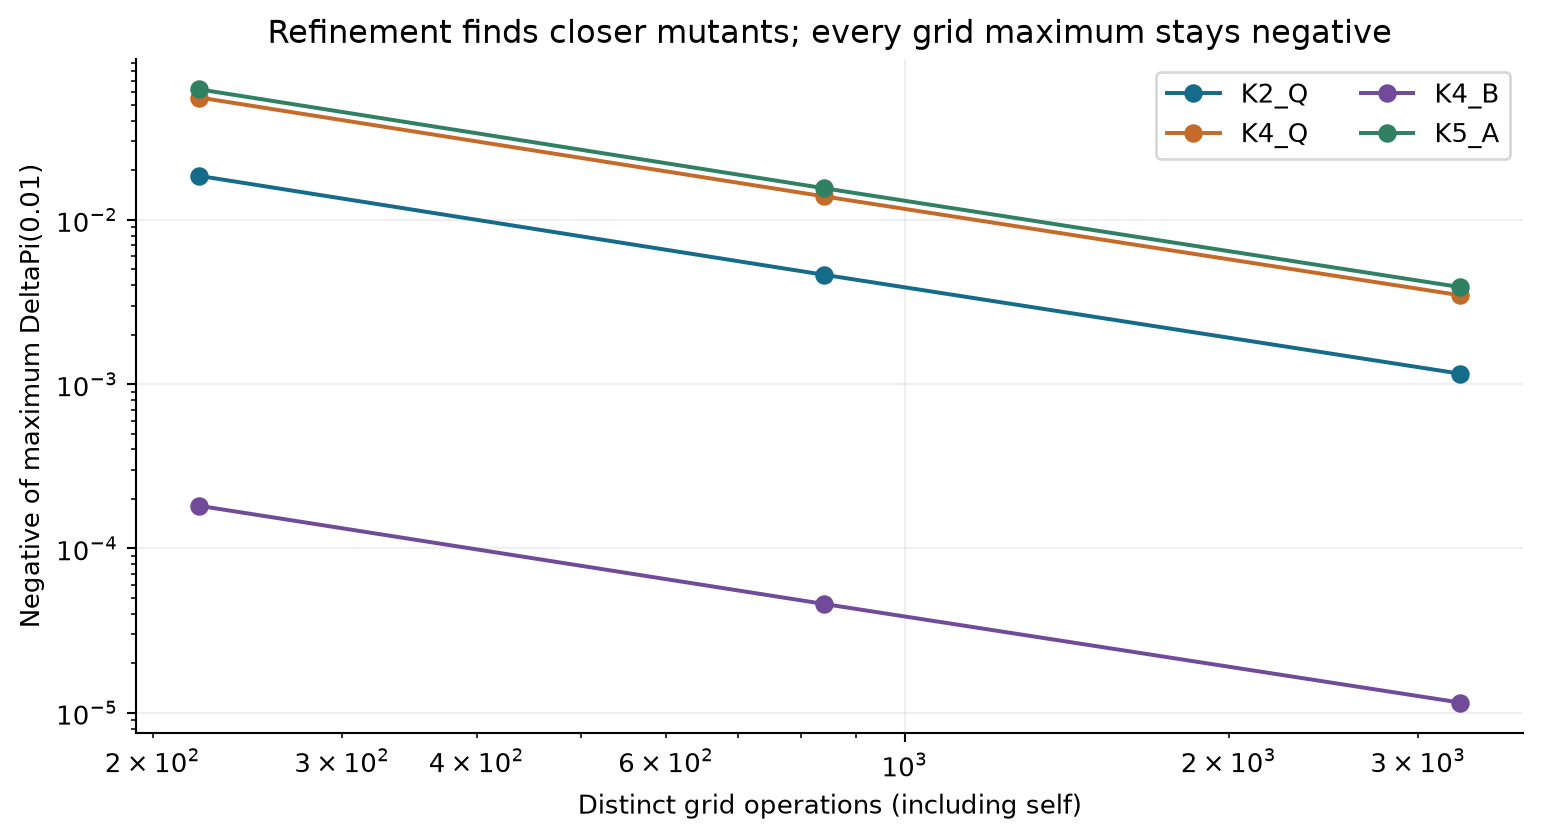

In [4]:
convergence=pd.read_csv(DATA/'grid_convergence.csv')
display(convergence)
display(Image(filename=str(DATA/'plots/grid_convergence.png')))

## Local geometry and boundary handling
B has a nonzero normal gradient and a zero a0 Hessian. Its tangent direction is controlled by the negative quadratic a1. The other three a0 Hessians are negative definite.

{'K2_Q': {'cone': 'dtheta>=0,dphi<=0',
  'a0': {'order': 0,
   'gradient': ['0', '0'],
   'hessian': [['-3/2', '0'], ['0', '-4']],
   'gradient_float': [0.0, 0.0],
   'hessian_float': [[-1.5, 0.0], [0.0, -4.0]],
   'eigenvalues': ['-3/2', '-4']},
  'null_resolution': 'negative definite a0 Hessian on all nonzero feasible directions'},
 'K4_Q': {'cone': 'dtheta>=0,dphi<=0',
  'a0': {'order': 0,
   'gradient': ['0', '0'],
   'hessian': [['-9/2', '0'], ['0', '-12']],
   'gradient_float': [0.0, 0.0],
   'hessian_float': [[-4.5, 0.0], [0.0, -12.0]],
   'eigenvalues': ['-9/2', '-12']},
  'null_resolution': 'negative definite a0 Hessian on all nonzero feasible directions'},
 'K4_B': {'cone': 'dphi<=0',
  'a0': {'order': 0,
   'gradient': ['0', '9/4'],
   'hessian': [['0', '0'], ['0', '0']],
   'gradient_float': [0.0, 2.25],
   'hessian_float': [[0.0, 0.0], [0.0, 0.0]],
   'eigenvalues': ['0']},
  'null_resolution': 'on dphi=0: a0 identically zero; a1=-3/4*sin(dtheta)^2=-3/4*dtheta^2+1/4*dtheta

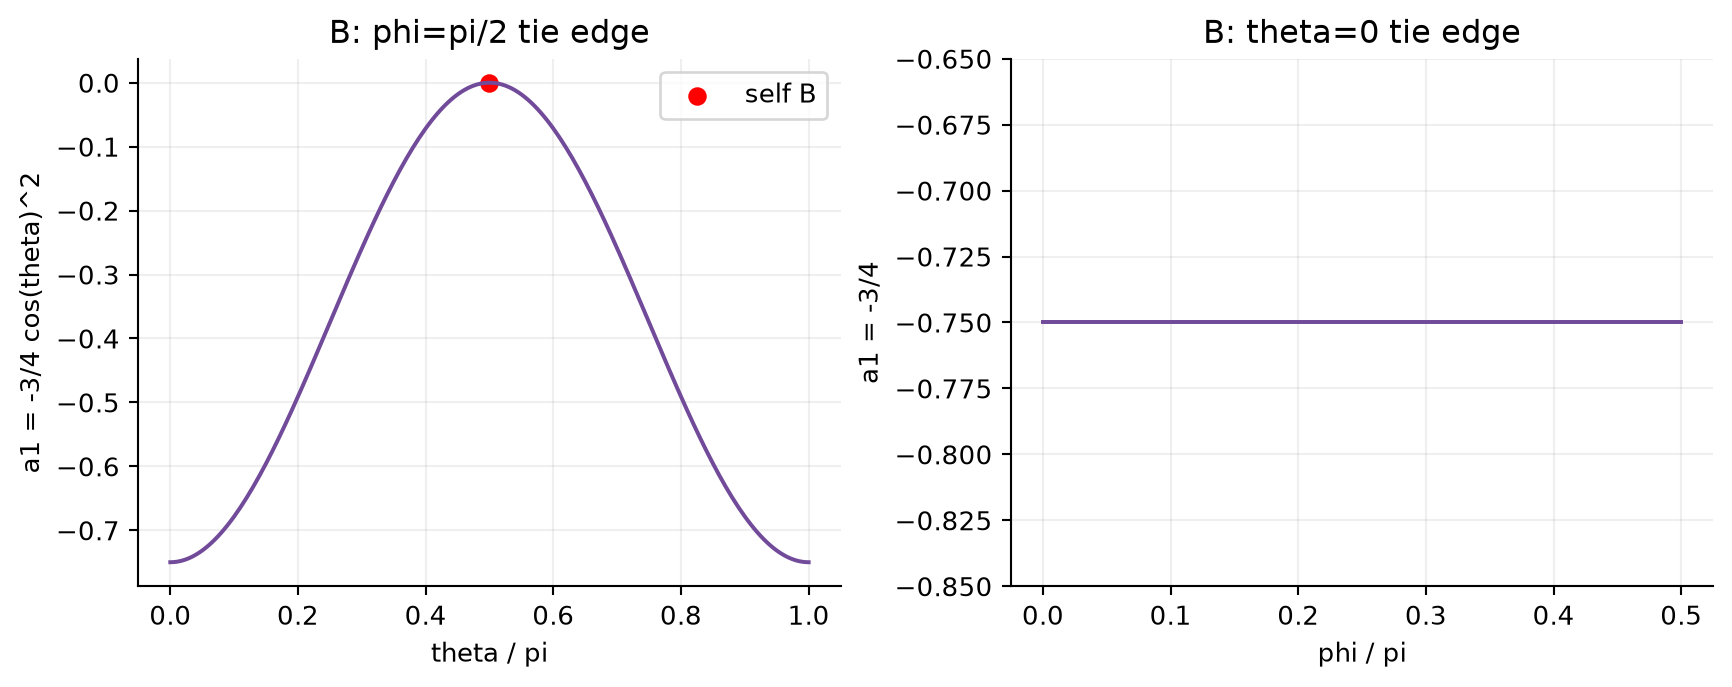

In [5]:
local=json.loads((DATA/'local_derivative_analysis.json').read_text())
display({name: {'cone':v['feasible_cone'],'a0':v['coefficients'][0], 'null_resolution':v['null_direction_resolution']} for name,v in local.items()})
display(Image(filename=str(DATA/'plots/B_tie_set.png')))

## Precision and optimizer transparency
Tiny numerical values are preserved as strings. There are 52 converged global searches and one failed local line search out of 32 local refinements. The proof does not depend on these optimizer outcomes.

In [6]:
precision=pd.read_csv(DATA/'precision_validation.csv',dtype=str)
display(precision[['resident','probe','high_precision_leading_order','high_precision_leading_value','max_double_error','ordinary_coordinates_collapse_to_self']])
optimizers=pd.read_csv(DATA/'coefficient_optimizer_runs.csv')
display(optimizers.groupby(['method','success']).size())
display(optimizers[~optimizers.success])

,resident,probe,high_precision_leading_order,high_precision_leading_value,max_double_error,ordinary_coordinates_collapse_to_self
0,K2_Q,ordinary,0,-1.1185850011201413331964075703700635256607010...,7.058152059996601e-16,False
1,K2_Q,near_theta_1e-8,0,-0.0000000000000000749999999999999993750000000...,7.5e-17,False
2,K2_Q,near_theta_1e-20,0,-7.5000000000000000000000000000000000000003079...,7.5e-41,False
3,K2_Q,near_phi_1e-20,0,-1.9999999999999999999999999999999999999999415...,4e-40,True
4,K2_Q,optimizer_best_double,0,-0.0000000000000000158072394697390774383752548...,1.580723946973908e-17,False
5,K2_Q,finest_grid_best,0,-0.0011564456389155978071077053585612891672774...,6.924242151474137e-16,False
6,K4_Q,ordinary,0,-3.3557550033604239995892227111101905769821031...,1.0622350366192821e-14,False
7,K4_Q,near_theta_1e-8,0,-0.0000000000000002249999999999999981250000000...,2.25e-16,False
8,K4_Q,near_theta_1e-20,0,-2.2500000000000000000000000000000000000000502...,2.25e-40,False
9,K4_Q,near_phi_1e-20,0,-5.9999999999999999999999999999999999999999090...,3.6e-39,True


method                  success
L-BFGS-B                False       1
                        True       31
differential_evolution  True       52
dtype: int64

,resident,coefficient_order,domain,method,seed,bounds,start,config,success,message,...,nfev,objective_value,constraint_violation,elapsed_seconds,theta,phi,distance,is_self,power_coefficients,delta_001
71,K5_A,0,full_rectangle,L-BFGS-B,20261002,"[[0.0,3.141592653589793],[0.0,1.57079632679489...","[1.7320972906990553,0.9266223065815113]","{""ftol"": 1e-14, ""gtol"": 1e-10, ""maxiter"": 1000}",False,ABNORMAL:,...,63,-1.037969e-16,0.0,0.000674,0.0,1.256637,3.602029e-09,False,"[0.0,0.0,0.0,0.0,1.7763568394002505e-15]",1.776357e-23


## Raw data and reproducible validator

In [7]:
raw=pd.read_csv(DATA/'mutant_coefficients.csv.gz')
assert len(raw)==17360
display(raw.groupby(['resident','stage','numerical_classification']).size())
display(raw[['resident','stage','u_R','u_M','bernstein_differences','power_coefficients']].head())
import importlib.util
spec=importlib.util.spec_from_file_location('validate_step6',ROOT/'scripts/validate_step6_results.py')
validator=importlib.util.module_from_spec(spec);spec.loader.exec_module(validator)
display(validator.validate(DATA))

resident  stage  numerical_classification
K2_Q      21x11  rare_mutant_rejected         220
          41x21  rare_mutant_rejected         840
          81x41  rare_mutant_rejected        3280
K4_B      21x11  rare_mutant_rejected         220
          41x21  rare_mutant_rejected         840
          81x41  rare_mutant_rejected        3280
K4_Q      21x11  rare_mutant_rejected         220
          41x21  rare_mutant_rejected         840
          81x41  rare_mutant_rejected        3280
K5_A      21x11  rare_mutant_rejected         220
          41x21  rare_mutant_rejected         840
          81x41  rare_mutant_rejected        3280
dtype: int64

,resident,stage,u_R,u_M,bernstein_differences,power_coefficients
0,K2_Q,21x11,"[3.0,1.0]","[1.0,3.0]","[-2.0,2.0]","[-2.0,4.0]"
1,K2_Q,21x11,"[3.0,1.0489434837048464]","[1.0489434837048464,2.809016994374948]","[-1.9510565162951536,1.7600735106701015]","[-1.9510565162951536,3.711130026965255]"
2,K2_Q,21x11,"[3.0,1.1909830056250523]","[1.1909830056250523,2.309016994374947]","[-1.8090169943749477,1.1180339887498947]","[-1.8090169943749477,2.9270509831248424]"
3,K2_Q,21x11,"[3.0,1.4122147477075269]","[1.4122147477075269,1.6909830056250525]","[-1.5877852522924731,0.2787682579175257]","[-1.5877852522924731,1.8665535102099988]"
4,K2_Q,21x11,"[3.0,1.6909830056250525]","[1.6909830056250525,1.190983005625053]","[-1.3090169943749475,-0.49999999999999956]","[-1.3090169943749475,0.8090169943749479]"


{'validation': 'passed',
 'mutant_rows': 17360,
 'grid_summaries': 12,
 'reconstruction_error': 1.4210854715202004e-14,
 'maximum_errors': {'focal_position_spread': 2.4868995751603507e-14,
  'placement_spread': 1.2434497875801753e-14,
  'probability_error': 1.6653345369377348e-15,
  'reconstruction_error': 7.105427357601002e-15},
 'optimizer_runs': 84,
 'global_converged': 52,
 'local_failed': 1,
 'high_precision_probes': 26,
 'exact_identities': 6}

## Next research step
Review the exact identities and zero sets. Step 7, only after authorization, adds full SU(2) and starts with a unilateral Nash screen. Restricted-family stability does not transfer automatically. The report includes the stored Iqbal-Toor and Benjamin-Hayden references and the future Steps 8-10 roadmap.